In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyRTC.hardware.ALPAODM import *
from pyRTC.utils import *

In [2]:
conf = read_yaml_file("/home/whetstone/pyRTC/SHARP_LAB/config.yaml")
confWFC = conf["wfc"]
wfc = ALPAODM(conf=confWFC)
time.sleep(0.5)
wfc.start()

Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta
Closing wfc
Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta
Opening Existing Shared Memory Object wfc2D
Opening Existing Shared Memory Object wfc2D_meta


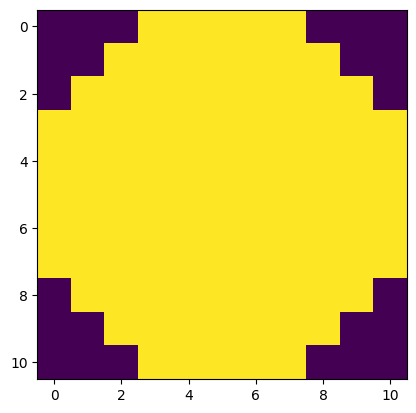

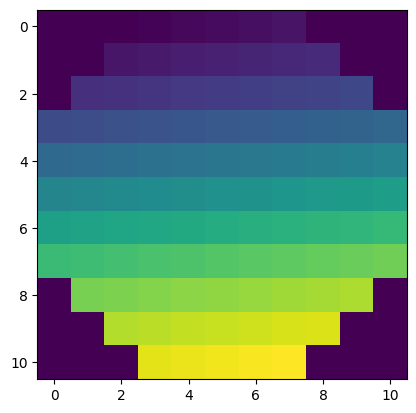

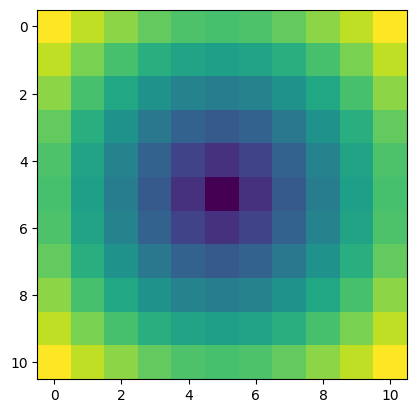

In [3]:
plt.imshow(wfc.layout)
plt.show()

## Starts indexing at 1
index_map = np.zeros(wfc.layout.shape, dtype = int)
index_map[wfc.layout > 0] = np.arange(np.sum(wfc.layout)).astype(int) + 1
plt.imshow(index_map)
plt.show()

xx,yy = np.meshgrid(np.arange(wfc.layout.shape[0]), np.arange(wfc.layout.shape[1]))
dist_map = np.sqrt((xx-wfc.layout.shape[0]//2)**2 + (yy-wfc.layout.shape[1]//2)**2)
plt.imshow(dist_map)
plt.show()

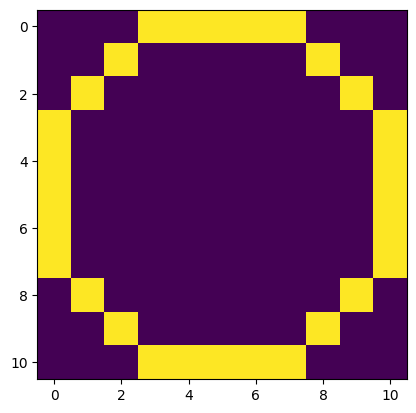

[ 0  1  2  3  4  5 11 12 20 21 31 32 42 43 53 54 64 65 75 76 84 85 91 92
 93 94 95 96]


In [4]:
act_to_float_mask = (index_map > 0) & (dist_map > 4.5)
plt.imshow(act_to_float_mask)
plt.show()


act_to_float_inds = index_map[act_to_float_mask] -1
print(act_to_float_inds)

np.save("floating_actuators_indices", act_to_float_inds)

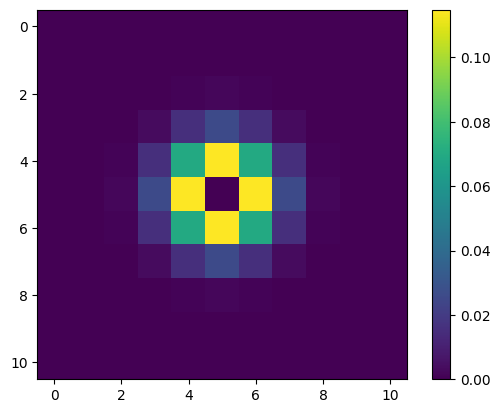

In [5]:
import numpy as np

def gaussian_2d_grid(i, j, sigma, grid_size):
    grid = np.zeros((grid_size, grid_size))
    for x in range(grid_size):
        for y in range(grid_size):
            if x == i and y == j:
                continue  # Skip the center point as its value should be 0
            else:
                # Compute the Gaussian value
                grid[x, y] = np.exp(-((x - i)**2 + (y - j)**2) / (2 * sigma**2))
    
    grid /= np.sum(grid)

    return grid

# Example of using the function with i, j = 5, 5 (center of the grid) and sigma = 1
gaussian_grid = gaussian_2d_grid(5, 5, 1, 11)
plt.imshow(gaussian_grid)
plt.colorbar()
plt.show()

/tmp/ipykernel_32520/747226879.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grid[x, y] = np.exp(-((x - i)**2 + (y - j)**2) / (2 * sigma**2))


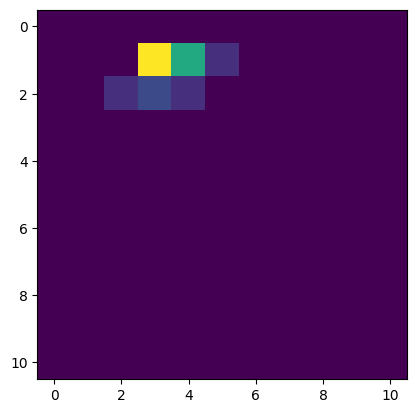

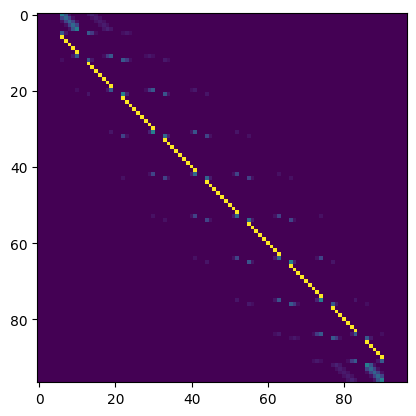

In [6]:
#Start with identity
float_matrix = np.eye(np.sum(wfc.layout))

#Remove floating actuators
grid_size = wfc.layout.shape[0]
influence_distance = 1
for n, act in enumerate(act_to_float_inds,1):

    #Get spatial location of the actuator
    i,j = np.where(index_map == act+1)
    #Get a gaussian region of influence
    inlfluence_map = gaussian_2d_grid(i,j, influence_distance, grid_size)
    #Apply the DM layout mask excluding other floating actuators
    inlfluence_map *= wfc.layout*(1-act_to_float_mask)
    #Renormalize to sum to 1
    inlfluence_map /= np.sum(inlfluence_map)
    #Set a bound on the lowest influence to a tenth of the maximum
    inlfluence_map[inlfluence_map < np.max(inlfluence_map)/10] = 0

    if n < 2:
        plt.imshow(inlfluence_map)
        plt.show()
    #Vectorize and add to matrix
    float_matrix[act] = inlfluence_map[wfc.layout>0]

plt.imshow(float_matrix)
plt.show()